In [22]:

import sys
print(sys.executable)


y:\Curriculum Mapping\transcript-ml\.venv\Scripts\python.exe


In [23]:

import ipykernel, pandas, catboost
print("✅ Everything is finally aligned")


✅ Everything is finally aligned


In [1]:
import pandas as pd

course_df = pd.read_csv(
    "../output/course_datapoints.tsv",
    sep="\t"
)

print(course_df.shape)
course_df.head()

(99442, 32)


C:\Users\beehm\AppData\Local\Temp\ipykernel_17332\4218403397.py:3: DtypeWarning: Columns (0: comments) have mixed types. Specify dtype option on import or set low_memory=False.
  course_df = pd.read_csv(


,student_id_hash,record_source,term,term_year,term_season,term_season_order,course_raw,course_id,course_subject,course_number,...,term_quality_points,term_gpa_hours,term_hours_earned,end_of_term_standing,course_load,current_gpa,final_gpa,program_code,curriculum_level,instructor_id
0,c143f3bbc9f46e5faa839883e83c3f4f4dbc28f3590ef7...,current_credit,Spring Semester 2026,2026,Spring,1,AMST-101-004,AMST-101,AMST,101,...,0.0,0.0,0.0,Good Standing,0.0,3.792,3.792,BIOM-APHZ-BS,Undergraduate,NaN
1,c143f3bbc9f46e5faa839883e83c3f4f4dbc28f3590ef7...,current_credit,Spring Semester 2026,2026,Spring,1,BMS-450-001,BMS-450,BMS,450,...,0.0,0.0,0.0,Good Standing,0.0,3.792,3.792,BIOM-APHZ-BS,Undergraduate,NaN
2,c143f3bbc9f46e5faa839883e83c3f4f4dbc28f3590ef7...,current_credit,Spring Semester 2026,2026,Spring,1,CHEM-344-L14,CHEM-344,CHEM,344,...,0.0,0.0,0.0,Good Standing,0.0,3.792,3.792,BIOM-APHZ-BS,Undergraduate,NaN
3,c143f3bbc9f46e5faa839883e83c3f4f4dbc28f3590ef7...,current_credit,Spring Semester 2026,2026,Spring,1,PH-122-001,PH-122,PH,122,...,0.0,0.0,0.0,Good Standing,0.0,3.792,3.792,BIOM-APHZ-BS,Undergraduate,NaN
4,c143f3bbc9f46e5faa839883e83c3f4f4dbc28f3590ef7...,current_credit,Summer Session 2026,2026,Summer,2,FSHN-444-401,FSHN-444,FSHN,444,...,0.0,0.0,0.0,NaN,0.0,3.792,3.792,BIOM-APHZ-BS,Undergraduate,NaN


In [24]:
completed = course_df[course_df["record_source"] == "completed_csu"].copy()

In [26]:
RISK_GRADES = {"D", "F", "W", "NP", "U"}

course_df["at_risk"] = (
    course_df["course_grade"]
    .fillna("")
    .str.upper()
    .isin(RISK_GRADES)
    .astype(int)
)

course_df[["course_grade", "at_risk"]].head(10)

,course_grade,at_risk
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0
5,NaN,0
6,NaN,0
7,NaN,0
8,NaN,0
9,NaN,0


In [27]:
course_df["at_risk"].value_counts(normalize=True)

at_risk
0    0.956236
1    0.043764
Name: proportion, dtype: float64

In [28]:
# Step 3: Feature selection

NUMERIC_FEATURES = [
    "course_credits",
    "term_gpa",
    "term_gpa_hours",
    "term_hours_earned",
    "current_gpa",
]

CATEGORICAL_FEATURES = [
    "course_subject",
    "course_number",
    "term_season",
    "curriculum_level",
    "program_code",
    "record_source",
]

FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = course_df[FEATURES]
y = course_df["at_risk"]
groups = course_df["student_id_hash"]

X.head()

,course_credits,term_gpa,term_gpa_hours,term_hours_earned,current_gpa,course_subject,course_number,term_season,curriculum_level,program_code,record_source
0,3.0,0.0,0.0,0.0,3.792,AMST,101,Spring,Undergraduate,BIOM-APHZ-BS,current_credit
1,3.0,0.0,0.0,0.0,3.792,BMS,450,Spring,Undergraduate,BIOM-APHZ-BS,current_credit
2,2.0,0.0,0.0,0.0,3.792,CHEM,344,Spring,Undergraduate,BIOM-APHZ-BS,current_credit
3,5.0,0.0,0.0,0.0,3.792,PH,122,Spring,Undergraduate,BIOM-APHZ-BS,current_credit
4,1.0,0.0,0.0,0.0,3.792,FSHN,444,Summer,Undergraduate,BIOM-APHZ-BS,current_credit


In [29]:
from catboost import CatBoostClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

In [30]:
model = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    verbose=False,
    random_seed=42,
)

In [31]:
def preprocess_categorical_features(df, categorical_features):
    """
    Prepare categorical features for CatBoost by handling NaN values and dtype.
    
    Parameters:
    -----------
    df : DataFrame - the feature matrix
    categorical_features : list of str - names of categorical columns
    
    Returns:
    --------
    DataFrame - copy with NaN values replaced and categorical columns as strings
    """
    df_processed = df.copy()
    
    for col in categorical_features:
        # Fill NaN values with "MISSING" string
        df_processed[col] = df_processed[col].fillna("MISSING")
        # Convert to string dtype
        df_processed[col] = df_processed[col].astype(str)
    
    return df_processed

# Preprocess X before cross-validation
X_processed = preprocess_categorical_features(X, CATEGORICAL_FEATURES)

print(f"Preprocessing complete.")
print(f"Categorical columns dtype: {X_processed[CATEGORICAL_FEATURES].dtypes.unique()}")
print(f"NaN values in categorical columns: {X_processed[CATEGORICAL_FEATURES].isna().sum().sum()}")


Preprocessing complete.
Categorical columns dtype: [<StringDtype(storage='python', na_value=nan)>]
NaN values in categorical columns: 0


In [32]:
# Fix categorical NaNs for CatBoost
X_cat_fixed = X.copy()

for col in CATEGORICAL_FEATURES:
    X_cat_fixed[col] = X_cat_fixed[col].fillna("MISSING").astype(str)

In [33]:
CATEGORICAL_FEATURES_NO_SOURCE = [
    "course_subject",
    "course_number",
    "term_season",
    "curriculum_level",
    "program_code",
]

FEATURES_NO_SOURCE = NUMERIC_FEATURES + CATEGORICAL_FEATURES_NO_SOURCE
X_no_source = course_df[FEATURES_NO_SOURCE].copy()

for col in CATEGORICAL_FEATURES_NO_SOURCE:
    X_no_source[col] = X_no_source[col].fillna("MISSING").astype(str)

In [13]:
cv = GroupKFold(n_splits=5)
aucs = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_cat_fixed, y, groups)):
    model.fit(
        X_cat_fixed.iloc[train_idx],
        y.iloc[train_idx],
        cat_features=CATEGORICAL_FEATURES,
    )

    preds = model.predict_proba(X_cat_fixed.iloc[test_idx])[:, 1]
    auc = roc_auc_score(y.iloc[test_idx], preds)
    aucs.append(auc)

    print(f"Fold {fold + 1} AUC: {auc:.3f}")

print(f"\nMean AUC: {sum(aucs)/len(aucs):.3f}")

Fold 1 AUC: 0.981
Fold 2 AUC: 0.983
Fold 3 AUC: 0.983
Fold 4 AUC: 0.974
Fold 5 AUC: 0.983

Mean AUC: 0.981


In [34]:
completed = course_df[course_df["record_source"] == "completed_csu"].copy()

In [35]:
import pandas as pd

course_df = pd.read_csv(
    "../output/course_datapoints.tsv",
    sep="\t"
)

course_df.shape

C:\Users\beehm\AppData\Local\Temp\ipykernel_17332\4168407772.py:3: DtypeWarning: Columns (0: comments) have mixed types. Specify dtype option on import or set low_memory=False.
  course_df = pd.read_csv(


(99442, 32)

In [36]:
# Define D/F/W (risk) indicator
RISK_GRADES = {"D", "F", "W"}

completed["is_dfw"] = completed["course_grade"].isin(RISK_GRADES)

In [37]:
completed["is_dfw"].value_counts(normalize=True)

is_dfw
False    0.935212
True     0.064788
Name: proportion, dtype: float64

In [38]:
dfw_by_course = (
    completed
    .groupby(["course_subject", "course_number"])
    .agg(
        enrollments=("is_dfw", "size"),
        dfw_rate=("is_dfw", "mean")
    )
    .query("enrollments >= 20")   # stability threshold
    .sort_values("dfw_rate", ascending=False)
)

dfw_by_course.head(10)

enrollments  dfw_rate
course_subject course_number                       
MATH           120                     90  0.300000
               161                     75  0.280000
MECH           103                     20  0.250000
PSY            192                     24  0.250000
POLS           241                     25  0.240000
ECON           204                     25  0.240000
HES            307                    132  0.227273
ANEQ           101                     31  0.225806
MATH           126                    102  0.215686
MGT            305                     28  0.214286

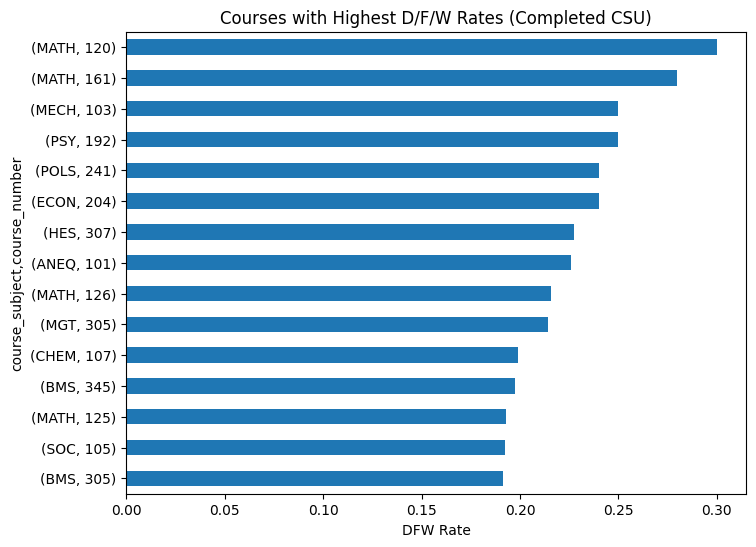

In [39]:
import matplotlib.pyplot as plt
# Plot top 15 courses by DFW rate
top_courses = dfw_by_course.head(15)

top_courses["dfw_rate"].plot(
    kind="barh",
    figsize=(8, 6)
)

plt.xlabel("DFW Rate")
plt.title("Courses with Highest D/F/W Rates (Completed CSU)")
plt.gca().invert_yaxis()  # highest at the top
plt.show()


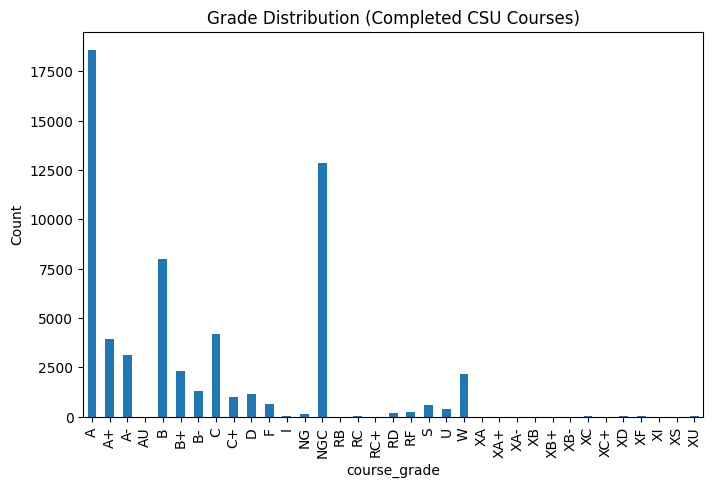

In [21]:
completed["course_grade"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Count")
plt.title("Grade Distribution (Completed CSU Courses)")
plt.show()


In [10]:
completed = course_df[course_df["record_source"] == "completed_csu"].copy()
completed["term_major"].isnull().mean()

major_course_timing = (
    completed
    .groupby(["term_major", "course_subject", "course_number", "term_year"])
    .size()
    .reset_index(name="count")
)

major_course_timing.head()

,term_major,course_subject,course_number,term_year,count
0,Aims Comm Coll Exchange Prog,OT,215,2025,1
1,Animal Science,ANEQ,101,2021,2
2,Animal Science,ANEQ,101,2022,8
3,Animal Science,ANEQ,101,2023,8
4,Animal Science,ANEQ,101,2024,8


In [40]:

major_course_timing = (
    completed
    .groupby(["term_major", "course_subject", "course_number", "term_year"])
    .size()
    .reset_index(name="enrollments")
)


In [41]:
major_course_avg_year = (
    major_course_timing
    .groupby(["term_major", "course_subject", "course_number"])
    .apply(
        lambda g: (g["term_year"] * g["enrollments"]).sum() / g["enrollments"].sum()
    )
    .reset_index(name="avg_year_taken")
)

major_course_avg_year.head()
completed["course_level"] = (
    completed["course_number"]
    .astype(str)
    .str.extract(r"(\d)")
    .astype(float) * 100
)
major_course_level = (
    completed
    .groupby(["term_major", "course_subject", "course_number", "course_level"]))

In [42]:
major_course_summary = (
    completed
    .groupby(["term_major", "course_subject", "course_number"])
    .agg(
        enrollments=("student_id_hash", "count"),
        median_year=("term_year", "median"),
        mean_year=("term_year", "mean")
    )
    .query("enrollments >= 20")
    .sort_values(["term_major", "mean_year"])
)

major_course_summary.head(20)

enrollments  median_year  \
term_major          course_subject course_number                             
Animal Science      LIFE           102                     20       2023.0   
                    ANEQ           101                     27       2023.0   
Biochemistry        BC             192                     46       2023.0   
                    LIFE           102                     44       2023.0   
                    CHEM           111                     48       2023.5   
                                   112                     22       2024.0   
                    LIFE           201B                    20       2024.0   
                                   203                     39       2024.0   
Biological Science  LIFE           102                    101       2023.0   
                    CO             150                     23       2023.0   
                    MATH           118                     22       2023.5   
                    CHEM           111                    114       2023.0   
                    MATH           124                     26       2023.0   
                                   125                     36       2023.5   
                    CHEM           112                     52       2024.0   
                    MATH           155                     26       2024.0   
                    LIFE           103                     84       2024.0   
                    CHEM           113                     41       2024.0   
                                   114                     38       2024.0   
Biomedical Sciences LIFE           162                     22       2023.0   

                                                    mean_year  
term_major          course_subject course_number               
Animal Science      LIFE           102            2022.800000  
                    ANEQ           101            2022.962963  
Biochemistry        BC             192            2022.826087  
                    LIFE           102            2022.954545  
                    CHEM           111            2023.041667  
                                   112            2023.136364  
                    LIFE           201B           2023.850000  
                                   203            2023.948718  
Biological Science  LIFE           102            2023.079208  
                    CO             150            2023.173913  
                    MATH           118            2023.227273  
                    CHEM           111            2023.263158  
                    MATH           124            2023.269231  
                                   125            2023.277778  
                    CHEM           112            2023.326923  
                    MATH           155            2023.423077  
                    LIFE           103            2023.642857  
                    CHEM           113            2023.780488  
                                   114            2023.789474  
Biomedical Sciences LIFE           162            2023.090909

In [27]:
bms301 = completed[
    (completed["course_subject"] == "BMS") &
    (completed["course_number"] == "301")
].copy()

bms301.shape

(1145, 33)

In [28]:
bms301_by_major = (
    bms301
    .groupby("term_major")
    .agg(
        enrollments=("student_id_hash", "count"),
        median_year=("term_year", "median"),
        mean_year=("term_year", "mean")
    )
    .sort_values("mean_year")
)

bms301_by_major


,enrollments,median_year,mean_year
term_major,,,
Biochemistry,6,2022.0,2022.000000
"Exp St: Hlth, Life, & Food Sci",3,2023.0,2023.000000
Biological Science,9,2023.0,2023.333333
Music,3,2024.0,2024.000000
Biomedical Sciences,509,2025.0,2024.821218
Health and Exercise Science,559,2025.0,2025.039356
Neuroscience,45,2025.0,2025.133333
Post Graduation Term,2,2026.0,2026.000000


## Major Group Mapping

In [43]:
# Ensure completed DataFrame is loaded
# Extract completed courses from the full course_df
if 'completed' not in locals():
    completed = course_df[course_df["record_source"] == "completed_csu"].copy()

# Define D/F/W (risk) indicator if not already present
if 'is_dfw' not in completed.columns:
    RISK_GRADES = {"D", "F", "W"}
    completed["is_dfw"] = completed["course_grade"].isin(RISK_GRADES)

print(f"✅ Completed courses loaded: {len(completed)} records, {completed['student_id_hash'].nunique()} unique students")


✅ Completed courses loaded: 60937 records, 2169 unique students


In [44]:
# Dictionary mapping program_code to major_group
program_to_major = {
    'BIOM-EPHZ-BS': 'Environmental and Public Health',
    'BIOM-APHZ-BS': 'Anatomy and Physiology',
    'BIOM-MIDZ-BS': 'Microbiology and Infectious Disease',
    'NERO-BCNZ-BS': 'Behavioral and Cognitive Neuroscience',
    'NERO-CMNZ-BS': 'Cell and Molecular Neuroscience',
    'NERO-BS': 'Neuroscience',
    'HAES-EXSZ-BS': 'Exercise Science',
    'HAES-BS': 'Exercise Science',
    'HAES-HPRZ-BS': 'Health Promotion'
}

In [45]:
# Create major_group column and fill missing values with "Other"
completed['major_group'] = completed['program_code'].map(program_to_major).fillna('Other')

# Group by major_group and calculate count and median term_year
major_group_summary = completed.groupby('major_group').agg({
    'program_code': 'count',
    'term_year': 'median'
}).rename(columns={'program_code': 'count'})

print(major_group_summary)

                                       count  term_year
major_group                                            
Anatomy and Physiology                 15619     2024.0
Behavioral and Cognitive Neuroscience   4059     2024.0
Cell and Molecular Neuroscience         2247     2024.0
Environmental and Public Health         1556     2024.0
Exercise Science                       20266     2024.0
Health Promotion                       10078     2024.0
Microbiology and Infectious Disease     5279     2024.0
Neuroscience                             288     2025.0
Other                                   1545     2025.0


## Curriculum Analytics Functions

In [46]:
def analyze_course_by_major(df, course_id, grade_col='course_grade'):
    """
    Analyze a single course's enrollment and outcomes across majors.
    
    Parameters:
    -----------
    df : DataFrame with columns: course_id, major_group, grade, term_year
    course_id : str - the course identifier
    grade_col : str - column name for grades (default 'grade')
    
    Returns:
    --------
    Dictionary with enrollment, grade distribution, DFW rate, and timing stats
    """
    course_data = df[df['course_id'] == course_id]
    
    if course_data.empty:
        return f"No data found for course {course_id}"
    
    # Calculate DFW (D, F, W grades)
    dfw_grades = ['D', 'F', 'W']
    course_data = course_data.copy()
    course_data['is_dfw'] = course_data[grade_col].isin(dfw_grades)
    
    # Group by major_group
    analysis = course_data.groupby('major_group').agg({
        'student_id_hash': 'count',  # enrollment count
        'is_dfw': 'sum',  # DFW count
        'term_year': ['median', 'mean'],
        grade_col: lambda x: x.value_counts().to_dict()  # grade distribution
    }).round(3)
    
    # Calculate DFW rate
    analysis[('dfw_rate', '')] = (
        course_data.groupby('major_group')['is_dfw'].mean()
    ).round(3)
    
    # Flatten column names
    analysis.columns = [f"{col[0]}_{col[1]}".strip('_') for col in analysis.columns]
    analysis = analysis.rename(columns={'student_id_hash_count': 'enrollment'})
    
    return analysis

# Example usage:
# analyze_course_by_major(completed, 'BIO101')

In [47]:
def find_shared_courses(df, major_groups=None):
    """
    Identify courses shared between major_groups and compute overlap statistics.
    
    Parameters:
    -----------
    df : DataFrame with columns: course_id, major_group
    major_groups : list of str - specific majors to analyze (None = all)
    
    Returns:
    --------
    DataFrame showing which majors take each course and overlap counts
    """
    if major_groups is None:
        major_groups = df['major_group'].unique()
    
    # Get courses by major
    courses_by_major = {
        major: set(df[df['major_group'] == major]['course_id'].unique())
        for major in major_groups
    }
    
    # Find shared courses
    shared_analysis = []
    for course in df['course_id'].unique():
        majors_with_course = [
            m for m, courses in courses_by_major.items() 
            if course in courses
        ]
        if len(majors_with_course) > 1:
            shared_analysis.append({
                'course_id': course,
                'num_majors': len(majors_with_course),
                'major_groups': ', '.join(sorted(majors_with_course)),
                'enrollment': len(df[df['course_id'] == course])
            })
    
    shared_df = pd.DataFrame(shared_analysis).sort_values('num_majors', ascending=False)
    return shared_df


def compute_major_overlap(df):
    """
    Compute pairwise course overlap between major_groups.
    
    Parameters:
    -----------
    df : DataFrame with columns: course_id, major_group
    
    Returns:
    --------
    DataFrame with overlap counts between each pair of majors
    """
    majors = df['major_group'].unique()
    courses_by_major = {
        major: set(df[df['major_group'] == major]['course_id'].unique())
        for major in majors
    }
    
    overlap_data = []
    for i, major1 in enumerate(majors):
        for major2 in majors[i+1:]:
            shared = len(courses_by_major[major1] & courses_by_major[major2])
            total1 = len(courses_by_major[major1])
            total2 = len(courses_by_major[major2])
            overlap_pct1 = (shared / total1 * 100) if total1 > 0 else 0
            overlap_pct2 = (shared / total2 * 100) if total2 > 0 else 0
            
            overlap_data.append({
                'major1': major1,
                'major2': major2,
                'shared_courses': shared,
                'overlap_%_of_major1': round(overlap_pct1, 1),
                'overlap_%_of_major2': round(overlap_pct2, 1)
            })
    
    return pd.DataFrame(overlap_data).sort_values('shared_courses', ascending=False)


def compare_timing_for_shared_courses(df, major1, major2):
    """
    For courses shared between two majors, compare when they typically take them.
    
    Parameters:
    -----------
    df : DataFrame with columns: course_id, major_group, term_year
    major1, major2 : str - major_group names to compare
    
    Returns:
    --------
    DataFrame showing median/mean term_year for shared courses by major
    """
    major1_courses = set(df[df['major_group'] == major1]['course_id'].unique())
    major2_courses = set(df[df['major_group'] == major2]['course_id'].unique())
    shared_courses = major1_courses & major2_courses
    
    shared_data = df[df['course_id'].isin(shared_courses)]
    
    timing_comparison = shared_data.groupby(['course_id', 'major_group']).agg({
        'term_year': ['median', 'mean', 'count']
    }).round(2)
    
    timing_comparison.columns = ['median_term', 'mean_term', 'count']
    return timing_comparison

# Example usage:
# find_shared_courses(completed)
# compute_major_overlap(completed)
# compare_timing_for_shared_courses(completed, 'Exercise Science', 'Health Promotion')

In [48]:
def compare_dfw_across_majors(df, course_id, grade_col='course_grade'):
    """
    Compare DFW (D, F, W) rates for the same course across different majors.
    
    Parameters:
    -----------
    df : DataFrame with columns: course_id, major_group, grade
    course_id : str - the course to analyze
    grade_col : str - column name for grades
    
    Returns:
    --------
    DataFrame with enrollment and DFW rates by major_group
    """
    course_data = df[df['course_id'] == course_id].copy()
    
    dfw_grades = ['D', 'F', 'W']
    course_data['is_dfw'] = course_data[grade_col].isin(dfw_grades)
    
    dfw_comparison = course_data.groupby('major_group').agg({
        'student_id_hash': 'count',
        'is_dfw': ['sum', 'mean']
    }).round(3)
    
    dfw_comparison.columns = ['enrollment', 'dfw_count', 'dfw_rate']
    dfw_comparison = dfw_comparison.sort_values('dfw_rate', ascending=False)
    
    return dfw_comparison


def analyze_timing_impact_on_outcomes(df, grade_col='course_grade', term_buckets=None):
    """
    Analyze how term_year (course timing) relates to DFW outcomes by major_group.
    
    Parameters:
    -----------
    df : DataFrame with columns: course_id, major_group, term_year, grade
    grade_col : str - column name for grades
    term_buckets : list of int - term_year cutoffs for grouping (e.g., [2, 3, 4])
    
    Returns:
    --------
    Dictionary with DFW rates by major_group and term grouping
    """
    data = df.copy()
    dfw_grades = ['D', 'F', 'W']
    data['is_dfw'] = data[grade_col].isin(dfw_grades)
    
    if term_buckets is None:
        # Default: Early (1-2), Middle (3-4), Late (5+)
        term_buckets = [2, 4]
    
    def assign_term_group(term):
        for i, bucket in enumerate(term_buckets):
            if term <= bucket:
                return f"Terms_1-{bucket}"
        return f"Terms_{term_buckets[-1]}+"
    
    data['term_group'] = data['term_year'].apply(assign_term_group)
    
    # Calculate DFW rate by major and term group
    timing_impact = data.groupby(['major_group', 'term_group']).agg({
        'student_id_hash': 'count',
        'is_dfw': 'mean'
    }).round(3)
    
    timing_impact.columns = ['enrollment', 'dfw_rate']
    
    return timing_impact


def generate_course_risk_summary(df, grade_col='course_grade'):
    """
    Generate a comprehensive risk summary for all courses by major_group.
    
    Parameters:
    -----------
    df : DataFrame with columns: course_id, major_group, grade, term_year
    grade_col : str - column name for grades
    
    Returns:
    --------
    DataFrame with enrollment, DFW rate, and median term for each course-major combo
    """
    data = df.copy()
    dfw_grades = ['D', 'F', 'W']
    data['is_dfw'] = data[grade_col].isin(dfw_grades)
    
    risk_summary = data.groupby(['course_id', 'major_group']).agg({
        'student_id_hash': 'count',
        'is_dfw': 'mean',
        'term_year': 'median'
    }).round(3)
    
    risk_summary.columns = ['enrollment', 'dfw_rate', 'median_term_year']
    risk_summary = risk_summary.sort_values(['dfw_rate', 'enrollment'], ascending=[False, False])
    
    return risk_summary

# Example usage:
# compare_dfw_across_majors(completed, 'BIO101')
# analyze_timing_impact_on_outcomes(completed)
# generate_course_risk_summary(completed)

In [49]:

completed["course_id"] = (
    completed["course_subject"] + "-" + completed["course_number"].astype(str)
)


## Usage Examples

In [50]:
# Single Course Analysis
print("=== Course Analysis by Major ===")
course_analysis = analyze_course_by_major(completed, 'CHEM-101')
print(course_analysis)

print("\n=== DFW Comparison Across Majors ===")
dfw_comparison = compare_dfw_across_majors(completed, 'CHEM-101')
print(dfw_comparison)

# Cross-Major Analysis
print("\n=== Courses Shared Between Majors ===")
shared = find_shared_courses(completed)
print(shared.head(10))

print("\n=== Major Overlap Matrix ===")
overlap = compute_major_overlap(completed)
print(overlap)

print("\n=== Timing Differences for Shared Courses ===")
timing = compare_timing_for_shared_courses(completed, 'Exercise Science', 'Health Promotion')
print(timing)

# Outcome Analysis
print("\n=== Timing Impact on DFW Rates ===")
timing_impact = analyze_timing_impact_on_outcomes(completed)
print(timing_impact)

print("\n=== Course Risk Summary (High Risk First) ===")
risk = generate_course_risk_summary(completed)
print(risk.head(15))

=== Course Analysis by Major ===
No data found for course CHEM-101

=== DFW Comparison Across Majors ===
Empty DataFrame
Columns: [enrollment, dfw_count, dfw_rate]
Index: []

=== Courses Shared Between Majors ===
    course_id  num_majors                                       major_groups  \
2    LIFE-210           9  Anatomy and Physiology, Behavioral and Cogniti...   
4     PSY-100           9  Anatomy and Physiology, Behavioral and Cogniti...   
30   POLS-131           9  Anatomy and Physiology, Behavioral and Cogniti...   
40  LIFE-201B           9  Anatomy and Physiology, Behavioral and Cogniti...   
58    CO-301B           9  Anatomy and Physiology, Behavioral and Cogniti...   
54     CO-150           9  Anatomy and Physiology, Behavioral and Cogniti...   
27   MATH-117           9  Anatomy and Physiology, Behavioral and Cogniti...   
28   MATH-118           9  Anatomy and Physiology, Behavioral and Cogniti...   
37   SPCM-100           9  Anatomy and Physiology, Behavioral and C

## Degree Requirements Analysis

In [51]:
def merge_with_requirements(completed, degree_reqs):
    """
    Merge completed courses with degree requirements data.
    
    Parameters:
    -----------
    completed : DataFrame with columns: student_id_hash, course_id, major_group, term_year, grade
    degree_reqs : DataFrame with columns: major_group, course_id, sequence_order, requirement_type
    
    Returns:
    --------
    DataFrame with completed courses joined with requirement info and expected timing
    """
    # Merge on major_group and course_id
    merged = completed.merge(
        degree_reqs,
        on=['major_group', 'course_id'],
        how='left'
    )
    
    # Mark whether course is required (not null requirement_type)
    merged['is_required'] = merged['requirement_type'].notna()
    
    return merged


def analyze_timing_vs_expected(merged_df, grade_col='course_grade'):
    """
    Compare actual course timing with expected sequence order.
    
    Parameters:
    -----------
    merged_df : DataFrame from merge_with_requirements (must have term_year, sequence_order)
    grade_col : str - column name for grades
    
    Returns:
    --------
    DataFrame with average actual term vs expected sequence by major and requirement type
    """
    # Filter to required courses only
    required = merged_df[merged_df['is_required'] == True].copy()
    
    timing_analysis = required.groupby(['major_group', 'requirement_type']).agg({
        'term_year': ['mean', 'median', 'std'],
        'sequence_order': ['mean', 'median'],
        'student_id_hash': 'count'
    }).round(2)
    
    timing_analysis.columns = ['_'.join(col).strip() for col in timing_analysis.columns.values]
    timing_analysis = timing_analysis.rename(columns={'student_id_hash_count': 'enrollment'})
    
    return timing_analysis


def check_required_courses_taken(completed, degree_reqs):
    """
    For each student-major combination, identify which required courses were taken.
    
    Parameters:
    -----------
    completed : DataFrame with columns: student_id_hash, major_group, course_id
    degree_reqs : DataFrame with columns: major_group, course_id, requirement_type
    
    Returns:
    --------
    DataFrame with per-student completion status of required courses
    """
    # Get all required courses by major
    required_by_major = degree_reqs[degree_reqs['requirement_type'].notna()].copy()
    
    # Get all student-major combinations
    student_majors = completed[['student_id_hash', 'major_group']].drop_duplicates()
    
    # Create expected courses for each student
    student_requirements = student_majors.merge(
        required_by_major[['major_group', 'course_id', 'requirement_type']],
        on='major_group'
    )
    
    # Get actually completed courses
    completed_courses = completed[['student_id_hash', 'major_group', 'course_id']].drop_duplicates()
    
    # Merge to show which required courses were completed
    requirement_status = student_requirements.merge(
        completed_courses,
        on=['student_id_hash', 'major_group', 'course_id'],
        how='left',
        indicator=True
    )
    
    requirement_status['completed'] = requirement_status['_merge'] == 'both'
    requirement_status = requirement_status.drop('_merge', axis=1)
    
    return requirement_status


def summarize_required_course_completion(completed, degree_reqs):
    """
    Summary: for each major, what % of required courses do students complete?
    
    Parameters:
    -----------
    completed : DataFrame with student enrollment data
    degree_reqs : DataFrame with requirement data
    
    Returns:
    --------
    DataFrame with completion rates and counts by major_group and requirement_type
    """
    requirement_status = check_required_courses_taken(completed, degree_reqs)
    
    summary = requirement_status.groupby(['major_group', 'requirement_type']).agg({
        'completed': ['sum', 'count', 'mean']
    }).round(3)
    
    summary.columns = ['num_completed', 'num_required', 'completion_rate']
    summary = summary.sort_values(['major_group', 'completion_rate'], ascending=[True, False])
    
    return summary


def required_course_overlap_between_majors(degree_reqs, major1, major2):
    """
    Find required courses that are the same vs different between two majors.
    
    Parameters:
    -----------
    degree_reqs : DataFrame with columns: major_group, course_id, requirement_type
    major1, major2 : str - major_group names
    
    Returns:
    --------
    Dictionary with shared vs unique required courses
    """
    req1 = set(
        degree_reqs[degree_reqs['major_group'] == major1]['course_id'].unique()
    )
    req2 = set(
        degree_reqs[degree_reqs['major_group'] == major2]['course_id'].unique()
    )
    
    shared = req1 & req2
    unique_to_1 = req1 - req2
    unique_to_2 = req2 - req1
    
    return {
        'major1': major1,
        'major2': major2,
        'shared_required_courses': len(shared),
        'unique_to_major1': len(unique_to_1),
        'unique_to_major2': len(unique_to_2),
        'shared_courses_list': sorted(list(shared)),
        'unique_to_major1_list': sorted(list(unique_to_1)),
        'unique_to_major2_list': sorted(list(unique_to_2))
    }

# Example usage:
# merged = merge_with_requirements(completed, degree_reqs)
# timing = analyze_timing_vs_expected(merged)
# completion = summarize_required_course_completion(completed, degree_reqs)
# overlap = required_course_overlap_between_majors(degree_reqs, 'Exercise Science', 'Health Promotion')

In [52]:
def detect_out_of_sequence_courses(merged_df):
    """
    Identify cases where students take courses earlier or later than recommended.
    
    Parameters:
    -----------
    merged_df : DataFrame from merge_with_requirements (must have term_year, sequence_order)
    
    Returns:
    --------
    DataFrame with out-of-sequence courses flagged and timing deviation
    """
    # Only analyze required courses
    required = merged_df[merged_df['is_required'] == True].copy()
    
    # Calculate deviation from expected sequence order
    # Assume sequence_order maps roughly to term_year (adjust if different scale)
    required['sequence_deviation'] = required['term_year'] - required['sequence_order']
    required['is_early'] = required['sequence_deviation'] < -0.5
    required['is_late'] = required['sequence_deviation'] > 0.5
    required['is_out_of_sequence'] = required['is_early'] | required['is_late']
    
    out_of_sequence = required[required['is_out_of_sequence'] == True].copy()
    out_of_sequence = out_of_sequence.sort_values('sequence_deviation', ascending=False)
    
    return out_of_sequence[['student_id_hash', 'major_group', 'course_id', 'requirement_type', 
                             'term_year', 'sequence_order', 'sequence_deviation', 'is_early', 'is_late']]


def out_of_sequence_summary(merged_df):
    """
    Summary statistics: how often do students take courses out of sequence by major?
    
    Parameters:
    -----------
    merged_df : DataFrame from merge_with_requirements
    
    Returns:
    --------
    DataFrame with out-of-sequence rates by major_group and requirement_type
    """
    required = merged_df[merged_df['is_required'] == True].copy()
    
    required['sequence_deviation'] = required['term_year'] - required['sequence_order']
    required['is_out_of_sequence'] = (required['sequence_deviation'].abs() > 0.5)
    
    summary = required.groupby(['major_group', 'requirement_type']).agg({
        'is_out_of_sequence': ['sum', 'count', 'mean'],
        'sequence_deviation': ['mean', 'std']
    }).round(3)
    
    summary.columns = ['num_out_of_sequence', 'total_courses', 'out_of_sequence_rate', 
                       'mean_deviation', 'std_deviation']
    summary = summary.sort_values('out_of_sequence_rate', ascending=False)
    
    return summary


def compare_required_vs_elective_outcomes(merged_df, grade_col='course_grade'):
    """
    Compare DFW rates and other outcomes for required vs elective courses.
    
    Parameters:
    -----------
    merged_df : DataFrame from merge_with_requirements (must have grade column)
    grade_col : str - column name for grades
    
    Returns:
    --------
    DataFrame with outcome comparison by major and requirement status
    """
    data = merged_df.copy()
    dfw_grades = ['D', 'F', 'W']
    data['is_dfw'] = data[grade_col].isin(dfw_grades)
    
    # Create label for course type
    data['course_type'] = data['is_required'].map({True: 'Required', False: 'Elective/Other'})
    
    outcomes = data.groupby(['major_group', 'course_type']).agg({
        'student_id_hash': 'count',
        'is_dfw': 'mean',
        'course_grade': lambda x: x.value_counts().to_dict()
    }).round(3)
    
    outcomes.columns = ['enrollment', 'dfw_rate', 'grade_distribution']
    outcomes = outcomes.sort_values('dfw_rate', ascending=False)
    
    return outcomes


def course_by_sequence_position_analysis(merged_df, grade_col='course_grade'):
    """
    Analyze outcomes by course sequence position (early, middle, late in degree).
    
    Parameters:
    -----------
    merged_df : DataFrame from merge_with_requirements (must have sequence_order)
    grade_col : str - column name for grades
    
    Returns:
    --------
    DataFrame with DFW rates and counts by sequence position and major
    """
    required = merged_df[merged_df['is_required'] == True].copy()
    dfw_grades = ['D', 'F', 'W']
    required['is_dfw'] = required[grade_col].isin(dfw_grades)
    
    # Categorize by sequence position (assuming sequence_order is 1-based)
    def assign_position(seq):
        if seq <= 2:
            return 'Early (1-2)'
        elif seq <= 4:
            return 'Middle (3-4)'
        else:
            return 'Late (5+)'
    
    required['sequence_position'] = required['sequence_order'].apply(assign_position)
    
    position_analysis = required.groupby(['major_group', 'sequence_position']).agg({
        'student_id_hash': 'count',
        'is_dfw': 'mean'
    }).round(3)
    
    position_analysis.columns = ['enrollment', 'dfw_rate']
    position_analysis = position_analysis.sort_values(['major_group', 'dfw_rate'], 
                                                       ascending=[True, False])
    
    return position_analysis

# Example usage:
# out_seq = detect_out_of_sequence_courses(merged)
# out_seq_summary = out_of_sequence_summary(merged)
# outcomes_comp = compare_required_vs_elective_outcomes(merged)
# position_analysis = course_by_sequence_position_analysis(merged)

## Degree Requirements Examples

In [53]:
# Load or create degree requirements data
# If you have a requirements file, load it:
# degree_reqs = pd.read_csv("path/to/degree_requirements.csv")

# Otherwise, create a sample structure:
degree_reqs = pd.DataFrame({
    'major_group': [
        'Exercise Science', 'Exercise Science', 'Exercise Science',
        'Health Promotion', 'Health Promotion', 'Health Promotion',
        'Exercise Science', 'Health Promotion'
    ],
    'course_id': [
        'EXSC101', 'EXSC201', 'EXSC301',
        'HPRO101', 'HPRO201', 'HPRO301',
        'BIOL201', 'BIOL201'
    ],
    'sequence_order': [1, 2, 3, 1, 2, 3, 2, 1],
    'requirement_type': [
        'Core', 'Core', 'Capstone',
        'Core', 'Core', 'Capstone',
        'Prerequisite', 'Prerequisite'
    ]
})

print("Degree Requirements Structure:")
print(degree_reqs)


Degree Requirements Structure:
        major_group course_id  sequence_order requirement_type
0  Exercise Science   EXSC101               1             Core
1  Exercise Science   EXSC201               2             Core
2  Exercise Science   EXSC301               3         Capstone
3  Health Promotion   HPRO101               1             Core
4  Health Promotion   HPRO201               2             Core
5  Health Promotion   HPRO301               3         Capstone
6  Exercise Science   BIOL201               2     Prerequisite
7  Health Promotion   BIOL201               1     Prerequisite


In [54]:

degree_reqs["course_id"] = (
    degree_reqs["course_id"]
    .str.replace(" ", "-", regex=False)
    .str.upper()
    .str.strip()
)


In [55]:
# Merge data
print("=== Merging Completed Courses with Degree Requirements ===")
merged = merge_with_requirements(completed, degree_reqs)
print(f"Merged data shape: {merged.shape}")
print(f"Courses with requirement info: {merged['is_required'].sum()} out of {len(merged)}")

# Timing Analysis
print("\n=== Actual vs Expected Course Timing ===")
timing = analyze_timing_vs_expected(merged)
print(timing)

# Required Course Completion
print("\n=== Required Course Completion Rates by Major ===")
completion = summarize_required_course_completion(completed, degree_reqs)
print(completion)

# Out of Sequence Detection
print("\n=== Out-of-Sequence Course Summary ===")
oos_summary = out_of_sequence_summary(merged)
print(oos_summary)

print("\n=== Students Taking Courses Out of Sequence ===")
oos_courses = detect_out_of_sequence_courses(merged)
print(oos_courses.head(20))

# Required vs Elective Outcomes
print("\n=== DFW Rates: Required vs Elective/Other Courses ===")
outcomes = compare_required_vs_elective_outcomes(merged)
print(outcomes)

# Sequence Position Analysis
print("\n=== Outcomes by Course Sequence Position ===")
position = course_by_sequence_position_analysis(merged)
print(position)

# Major-to-Major Requirement Comparison
print("\n=== Comparing Required Courses Between Majors ===")
majors = degree_reqs['major_group'].unique()
for i, major1 in enumerate(majors[:3]):  # Sample first 3 majors
    for major2 in majors[i+1:i+2]:
        overlap = required_course_overlap_between_majors(degree_reqs, major1, major2)
        print(f"\n{major1} vs {major2}:")
        print(f"  Shared required courses: {overlap['shared_required_courses']}")
        print(f"  Unique to {major1}: {overlap['unique_to_major1']}")
        print(f"  Unique to {major2}: {overlap['unique_to_major2']}")
        print(f"  Shared: {overlap['shared_courses_list']}")

=== Merging Completed Courses with Degree Requirements ===
Merged data shape: (60937, 39)
Courses with requirement info: 0 out of 60937

=== Actual vs Expected Course Timing ===
Empty DataFrame
Columns: [term_year_mean, term_year_median, term_year_std, sequence_order_mean, sequence_order_median, enrollment]
Index: []

=== Required Course Completion Rates by Major ===
                                   num_completed  num_required  \
major_group      requirement_type                                
Exercise Science Capstone                      0           756   
                 Core                          0          1512   
                 Prerequisite                  0           756   
Health Promotion Capstone                      0           303   
                 Core                          0           606   
                 Prerequisite                  0           303   

                                   completion_rate  
major_group      requirement_type               

In [56]:
# Create course_id

# Ensure required columns exist
completed["course_id"] = (
    completed["course_subject"].str.upper() + "-" +
    completed["course_number"].astype(str)
)

completed["major_group"] = completed["program_code"].map(program_to_major).fillna("Other")
completed["is_dfw"] = completed["course_grade"].isin({"D", "F", "W"})


In [57]:
presentation_table = completed.dropna(
    subset=[
        "course_id",
        "major_group",
        "term_year",
        "course_grade",
        "term_class_level"
    ]
).copy()

In [61]:
# Extract section (last part after dash)
presentation_table["section"] = presentation_table["course_raw"].str.split("-").str[-1]

In [62]:
def classify_section(section):
    section = str(section)

    if section.startswith("L"):
        return "Lab"
    elif section.startswith("R"):
        return "Recitation"
    else:
        return "Lecture"

presentation_table["section_type"] = presentation_table["section"].apply(classify_section)

In [95]:
course_major_timing_report = (
    presentation_table
    .groupby([
        "course_id",
        "section_type",   # ✅ ADD THIS LINE
        "major_group",
        "term_year",
        "term_season",
        "term_class_level",
        "course_grade"
    ])
    .size()
    .reset_index(name="enrollments")
    .sort_values([
        "course_id",
        "section_type",   # ✅ ADD HERE TOO (for clean sorting)
        "major_group",
        "term_year",
        "term_season"
    ])
)

course_major_timing_report.head(20)

,course_id,section_type,major_group,term_year,term_season,term_class_level,course_grade,enrollments
0,AA-100,Lecture,Anatomy and Physiology,2025,Spring,Junior,A,1
1,AA-100,Lecture,Anatomy and Physiology,2025,Summer,Junior,A,1
2,AA-100,Lecture,Behavioral and Cognitive Neuroscience,2025,Fall,Senior,F,1
3,AA-100,Lecture,Exercise Science,2022,Fall,Freshman,B,1
4,AA-100,Lecture,Exercise Science,2023,Fall,Freshman,B+,1
5,AA-100,Lecture,Exercise Science,2023,Fall,Freshman,C+,1
6,AA-100,Lecture,Exercise Science,2023,Fall,Freshman,W,1
7,AA-100,Lecture,Exercise Science,2023,Spring,Sophomore,B,1
8,AA-100,Lecture,Exercise Science,2024,Fall,Freshman,C,1
9,AA-100,Lecture,Exercise Science,2024,Spring,Sophomore,B,1


In [96]:
course_major_timing_report.to_csv("course_major_timing_report_with_sections.csv", index=False)

In [64]:
behavior_table = (
    presentation_table
    .groupby([
        "course_id",
        "major_group",
        "term_class_level",
        "term_season",
        "course_grade"
    ])
    .size()
    .reset_index(name="count")
)

In [65]:
grade_dominance = (
    behavior_table
    .sort_values("count", ascending=False)
    .drop_duplicates(
        ["course_id", "major_group", "term_class_level", "term_season"]
    )
)


In [66]:
def get_mode(series):
    return series.mode().iloc[0] if not series.mode().empty else None


In [67]:
lecture_data = presentation_table[
    presentation_table["section_type"] == "Lecture"
]

In [68]:
course_summary = (
    lecture_data
    .groupby(["course_id", "major_group"])
    .agg(
        total_enrollments=("course_grade", "count"),
        most_common_grade=("course_grade", lambda x: x.mode()[0]),
        most_common_level=("term_class_level", lambda x: x.mode()[0]),
        most_common_term=("term_season", lambda x: x.mode()[0])
    )
    .reset_index()
)


In [69]:
course_summary_all = (
    presentation_table
    .groupby(["course_id", "major_group"])
    .agg(
        total_enrollments=("course_grade", "count"),
        most_common_grade=("course_grade", lambda x: x.mode()[0]),
        most_common_level=("term_class_level", lambda x: x.mode()[0]),
        most_common_term=("term_season", lambda x: x.mode()[0])
    )
    .reset_index()
)

In [70]:
course_summary["timing"] = (
    course_summary["most_common_level"] +
    " (" + course_summary["most_common_term"] + ")"
)

In [93]:
course_summary["timing"] = (
    course_summary["most_common_level"] + " (" + course_summary["most_common_term"] + ")"
)

# also for full dataset
course_summary_all["timing"] = (
    course_summary_all["most_common_level"] + " (" + course_summary_all["most_common_term"] + ")"
)

In [71]:
pivot_table = course_summary.pivot(
    index="course_id",
    columns="major_group",
    values="timing"
)

In [72]:
course_summary["timing_grade"] = (
    course_summary["most_common_level"] +
    " (" + course_summary["most_common_term"] + ")" +
    " | " +
    course_summary["most_common_grade"]
)

pivot_table_full = course_summary.pivot(
    index="course_id",
    columns="major_group",
    values="timing_grade"
)

In [73]:
course_summary.to_csv("behavioral_curriculum_summary.csv", index=False)
pivot_table.to_csv("behavioral_curriculum_timing.csv")
pivot_table_full.to_csv("behavioral_curriculum_with_grades.csv")

In [74]:
course_summary = pd.read_csv("behavioral_curriculum_summary.csv")

In [75]:
def ask(df, course=None, major=None):
    result = df.copy()

    if course:
        result = result[result["course_id"] == course]

    if major:
        result = result[result["major_group"] == major]

    return result.sort_values(["course_id"])

In [6]:
#test queries
ask(course_summary, course="CHEM-111")
ask(course_summary, major="Exercise Science")


,course_id,major_group,total_enrollments,most_common_grade,most_common_level,most_common_term,timing,timing_grade
2,AA-100,Exercise Science,3,B,Freshman,Fall,Freshman (Fall),Freshman (Fall) | B
5,AA-101,Exercise Science,2,A,Freshman,Fall,Freshman (Fall),Freshman (Fall) | A
12,ACT-205,Exercise Science,8,A,Junior,Fall,Junior (Fall),Junior (Fall) | A
17,ACT-210,Exercise Science,3,A,Sophomore,Fall,Sophomore (Fall),Sophomore (Fall) | A
21,ACT-220,Exercise Science,1,A,Junior,Fall,Junior (Fall),Junior (Fall) | A
...,...,...,...,...,...,...,...,...
3217,VS-495,Exercise Science,1,S,Sophomore,Fall,Sophomore (Fall),Sophomore (Fall) | S
3220,WR-204,Exercise Science,1,B+,Freshman,Spring,Freshman (Spring),Freshman (Spring) | B+
3224,WS-200,Exercise Science,1,A,Senior,Fall,Senior (Fall),Senior (Fall) | A
3228,WS-270,Exercise Science,1,A,Freshman,Fall,Freshman (Fall),Freshman (Fall) | A


In [7]:
courses = course_summary["course_id"].str.lower().unique().tolist()
majors = course_summary["major_group"].str.lower().unique().tolist()

In [97]:
# normalize course formats
def normalize_course(text):
    text = text.replace(" ", "").lower()
    return text

course_lookup = {
    c.lower().replace("-", ""): c
    for c in course_summary["course_id"].unique()
}

# major aliases (you can expand this easily)
major_aliases = {
    # Exercise Science
    "exercise science": "Exercise Science",
    "ex sci": "Exercise Science",
    "exscience": "Exercise Science",
    "exercise sci": "Exercise Science",

    # Health Promotion
    "health promotion": "Health Promotion",
    "hp": "Health Promotion",
    "health promo": "Health Promotion",

    # Biology
    "biology": "Biology",
    "bio": "Biology",

    # Anatomy & Physiology
    "anatomy and physiology": "Anatomy and Physiology",
    "a&p": "Anatomy and Physiology",
    "anatomy": "Anatomy and Physiology",
    "physiology": "Anatomy and Physiology",

    # Microbiology and Infectious Disease
    "microbiology and infectious disease": "Microbiology and Infectious Disease",
    "microbiology": "Microbiology and Infectious Disease",
    "infectious disease": "Microbiology and Infectious Disease",
    "mmid": "Microbiology and Infectious Disease",
    "mid": "Microbiology and Infectious Disease",

    #environmental and public health
    "environmental and public health": "Environmental and Public Health",
    "environmental health": "Environmental and Public Health",
    "public health": "Environmental and Public Health",
    "eph": "Environmental and Public Health",

    #Neruoscience
    "neuroscience": "Neuroscience",
    "neuro": "Neuroscience",
    #behavioral and cognitive neuroscience
    "behavioral and cognitive neuroscience": "Behavioral and Cognitive Neuroscience",
    "bcn": "Behavioral and Cognitive Neuroscience",
    #cell and molecular neuroscience
    "cell and molecular neuroscience": "Cell and Molecular Neuroscience",
    "cmn": "Cell and Molecular Neuroscience",

}

In [106]:
def chatbot(question, df_lecture, df_all):
    # --- CLEAN QUESTION ---
    question_lower = question.lower()
    words = question_lower.replace(",", "").replace("?", "").split()

    # --- DATASET SELECTION (lecture vs lab) ---
    use_all = False
    if any(word in question_lower for word in ["lab", "labs", "recitation", "rec", "discussion"]):
        use_all = True

    df = df_all if use_all else df_lecture

    # --- COURSE DETECTION ---
    course = None
    q_clean = question_lower.replace(" ", "").replace("-", "")

    for key, value in course_lookup.items():
        if key in q_clean:
            course = value
            break

    # --- MAJOR DETECTION (fixed version ✅) ---
    major = None

    for key, value in major_aliases.items():
        key_words = key.split()

        # check if all parts of alias appear in the question
        if all(word in words for word in key_words):
            major = value
            break

    # fallback: exact full-name match
    if not major:
        for m in df_lecture["major_group"].unique():
            if m.lower() in question_lower:
                major = m
                break

    # --- VALIDATION ---
    if not course:
        return "I couldn't detect the course. Try something like 'CHEM 111'."

    # --- LEVEL DETECTION ---
    level = None
    for l in ["freshman", "sophomore", "junior", "senior"]:
        if l in question_lower:
            level = l.capitalize()
            break

    # --- TERM DETECTION ---
    term = None
    for t in ["fall", "spring", "summer"]:
        if t in question_lower:
            term = t.capitalize()
            break

    # --- APPLY FILTERS ---
    result = df

    if course:
        result = result[result["course_id"] == course]

    if major:
        result = result[result["major_group"] == major]

    if level:
        result = result[result["most_common_level"] == level]

    if term:
        result = result[result["most_common_term"] == term]

    # --- HANDLE EMPTY RESULT ---
    if result.empty:
        return "I couldn't find a matching result. Try rephrasing your question."

    # --- RESPONSE TYPE (labeling) ---
    data_type = "all sections (including labs/recitations)" if use_all else "lecture sections only"

    # --- BUILD RESPONSE ---
    responses = []

    for _, row in result.head(5).iterrows():
        if major:
            responses.append(
                f"{row['course_id']} for {row['major_group']} students is typically taken in "
                f"{row['most_common_level']} ({row['most_common_term']}) and the most common grade is "
                f"{row['most_common_grade']} ({data_type})."
            )
        else:
            responses.append(
                f"{row['course_id']} across all majors is typically taken in "
                f"{row['most_common_level']} ({row['most_common_term']}) and the most common grade is "
                f"{row['most_common_grade']} ({data_type})."
            )

    return "\n".join(responses)

In [107]:
while True:
    q = input("Ask a question (type 'exit' to quit): ")

    if q.lower() in ["exit", "quit"]:
        print("Chatbot stopped.")
        break

    answer = chatbot(q, course_summary, course_summary_all)
    print(answer)

BMS-301 for Environmental and Public Health students is typically taken in Senior (Fall) and the most common grade is B (lecture sections only).
Chatbot stopped.


In [12]:
print(len(courses))
print(len(majors))

1099
9
